# Siparişler

In [1]:
import sys
import os

sys.path.append(os.getcwd())

✏️ **Alıştırma**

Bugün **siparişleri** ve bunlara ait **değerlendirme puanını (review score)** inceleyeceğiz.

👉 Amacımız aşağıdaki özelliklere sahip bir DataFrame oluşturmaktır:


| özellik_adı  	| tip  	| açıklama  	|
|:---	|:---:	|:---	|
| `order_id` 	| str 	| siparişin kimliği (id) 	|
| `wait_time` 	| float 	| `order_purchase_timestamp` ile `order_delivered_customer_date` arasındaki gün sayısı 	|
| `expected_wait_time` 	| float 	| `order_purchase_timestamp` ile `estimated_delivery_date` arasındaki beklenen gün sayısı 	|
| `delay_vs_expected` 	| float 	| gerçek `order_delivered_customer_date` tahmini teslim tarihinden sonra ise iki tarih arasındaki gün sayısını döndürür, aksi halde 0 döndürür 	|
| `order_status` 	| str 	| siparişin durumu 	|
| `dim_is_five_star` 	| int 	| sipariş beş yıldız aldıysa 1, aksi halde 0 	|
| `dim_is_one_star` 	| int 	| sipariş bir yıldız aldıysa 1, aksi halde 0 	|
| `review_score` 	| int 	| 1 ile 5 arasında 	|
| `number_of_items` 	| int 	| siparişin içerdiği toplam ürün sayısı 	|
| `number_of_sellers` 	| int 	| siparişte yer alan satıcı sayısı 	|
| `price` 	| float 	| müşterinin ödediği toplam sipariş fiyatı 	|
| `freight_value` 	| float 	| müşterinin ödediği kargo ücreti 	|
| `distance_customer_seller` 	| float 	| müşteri ile satıcı arasındaki mesafe (km, isteğe bağlı) 	|  

⚠️ Ayrıca "teslim edilmemiş" siparişleri filtrelemeliyiz; aksi belirtilmedikçe bunları dahil etmeyin, çünkü potansiyel gecikmeleri hesaplayamayız.

❓ **Senin görevin**: 

- Her bir özelliği `olist/order.py` içindeki `Order` sınıfında ayrı bir metod olarak uygulayın
- Ardından, eksiksiz DataFrame'i **`NaN` içermeyecek şekilde** döndüren `get_training_data()` metodunu oluşturun.

💡 Önerilen yöntem:
- Önce aşağıdaki notebook'u kullanarak kodunuzu adım adım yazıp test edin
- Kod mantığınızdan emin olduktan sonra kodu `order.py` dosyasına kopyalayın
- Şimdilik veri işleme mantığına odaklanın; veriyi görselleştirmeyi sonraki alıştırmalarda yapacağız

🔥 Notebook için en iyi uygulamalar (okumanız zorunludur) 👇

<details>
    <summary>▸ <i>tıklayın</i></summary>

Bundan sonra keşif amaçlı notebook'lar oldukça uzun olabilir; bu nedenle aşağıdaki ilkeleri takip etmenizi şiddetle tavsiye ediyoruz:
- Kodunuzu, Notebook her zaman baştan sona çalıştırıldığında çökmeden çalışacak şekilde yazın (Run --> Run All Cells)
- Değişken adlarını dikkatli seçin
- Kısa süreyle kullanılacak ara adımlar için `tmp` veya `_` gibi geçici isimler kullanın
- Notebook boyutunu azaltmak için kodunuzu temizleyin ve hücreleri birleştirin (`Shift-M`)
- Katlanabilir başlıklar ve içerik tablosunu sıkça kullanın (bulamazsanız bir TA'ya danışın)
- Aşağıdaki kısayolları kullanın
    - `a` bir hücre üstüne ekler
    - `b` bir hücre alta ekler
    - `dd` bir hücreyi siler
    - `esc` ve `ok` tuşları ile hücreler arası gezinme
    - `Shift-Enter` hücreyi çalıştırır ve sonraki hücreye geçer
    - parantez içindeyken örn. `groupby()` üzerinde `Shift + Tab` kullanarak dokümantasyona bakabilirsiniz. Birkaç kez tekrar edin, kalıcı olarak açmak için

</details>

In [2]:
# Auto reload imported module every time a jupyter cell is executed (handy for olist.order.py updates)
%load_ext autoreload
%autoreload 2

In [3]:
# Import usual modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

In [5]:
# Import olist data
from olist.data import Olist
olist = Olist()
data = olist.get_data()

In [6]:
# What datasets do we have access to now ?
data.keys()

dict_keys(['orders', 'order_items', 'order_reviews', 'products', 'sellers', 'customers', 'geolocation'])

In [7]:
orders = data['orders'].copy() # good practice to be sure not to modify your `data` variable

assert(orders.shape == (99441, 8))

## 1. `order.py` dosyasını kodlayın

### a) `get_wait_time`
    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
           `order_id`, `wait_time`, `expected_wait_time`, `delay_vs_expected`, `order_status`



🎁 Bu ilk metod için aşağıda size pseudo-kod veriyoruz 👇

> 1. `orders` DataFrame'ini inceleyin
2. DataFrame'i `teslim edilmiş (delivered)` siparişler üzerine filtreleyin
3. `datetime` ile çalışmayı düzenleyin
    - Python [`datetime`](https://docs.python.org/3/library/datetime.html) nesnelerinin ne olduğunu anlamaya zaman ayırın
    - ve tarihleri "string" tipinden `pandas.to_datetime()` kullanarak `pandas.datetime` tipine dönüştürün
4. `order_purchase_timestamp`'tan başlayarak `wait_time`'ı gün cinsinden ondalıklı bir sayı olarak hesaplayın
5. `expected_wait_time`'ı `order_purchase_timestamp`'tan başlayarak gün cinsinden hesaplayın
6. `delay_vs_expected`'i gün cinsinden hesaplayın (sipariş tahmini teslim tarihinden daha erken teslim edildiyse 0 koyun)
7. Yeni DataFrame'i kontrol edin
8. Kodunuzdan memnun kaldığınızda, notebook'tan `olist/order.py`'ye dikkatlice kopyalayabilirsiniz
9. Şimdi metodunuzu `orders.py` içinde çağırmayı deneyin
10. Kodunuz muhtemelen hemen çalışmayacaktır
11. `.py` dosyası içinde çalışacak şekilde gerekli değişiklikleri yapın

`wait_time`, `expected_wait_time` ve `delay_vs_expected`'in tam sayı değil ondalıklı gün cinsinden olmasını istiyoruz. Düşünün: 8.1 veya 8.9 günlük bir bekleme büyük fark yaratır. Bu yüzden Pandas'ın `dt.day` özelliklerini kullanmayın; çünkü bu değerleri aşağı yuvarlar.

<details>
    <summary>💡İpucu</summary>

Hem `wait_time` hem de `delay_vs_expected` için ilgili tarihler arasındaki farkı almak üzere tarihleri çıkarmanız gerekir. Ardından bu farkın kaç günü temsil ettiğini bulmak için ya [`datetime.timedelta()`](https://docs.python.org/3/library/datetime.html#timedelta-objects) ya da [`np.timedelta64()`](https://numpy.org/doc/stable/reference/arrays.datetime.html#datetime-and-timedelta-arithmetic) kullanabilirsiniz!

</details>

In [8]:
# YOUR CODE HERE

👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [9]:
# Test your code here
from olist.order import Order
Order().get_wait_time()

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,15,0.0,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,19,0.0,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,26,0.0,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,26,0.0,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,12,0.0,delivered
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,8.0,18,0.0,delivered
99437,63943bddc261676b46f01ca7ac2f7bd8,22.0,23,0.0,delivered
99438,83c1379a015df1e13d02aae0204711ab,24.0,30,0.0,delivered
99439,11c177c8e97725db2631073c19f07b62,17.0,37,0.0,delivered


In [10]:
from nbresult import ChallengeResult
test = Order().get_wait_time()
result = ChallengeResult('wait_time', dve_type=test["delay_vs_expected"].dtype, shape=test.shape, dve_min=test["delay_vs_expected"].min(), dve_max=test["delay_vs_expected"].max())
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- /home/doruk/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/doruk/data-orders
configfile: pytest.ini
plugins: anyio-4.13.0
collecting ... collected 1 item

test_wait_time.py::TestWaitTime::test_wait_time PASSED                   [100%]

============================== 1 passed in 0.12s ===============================


💯 You can commit your code:

git add tests/wait_time.pickle

git commit -m 'Completed wait_time step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### b) `get_review_score`
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `dim_is_five_star`, `dim_is_one_star`, `review_score`

`dim_is_$N$_star` sütunu `review_score=$N$` ise `1`, değilse `0` içermelidir

<details>
    <summary markdown='span'>İpuçları</summary>

`Series.map()` veya `DataFrame.apply()` üzerine düşünün
    
</details>

👉 We load the `reviews` for you

In [11]:
reviews = data['order_reviews'].copy()
assert(reviews.shape == (99224,7))
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [12]:
review_score = reviews[["order_id", "review_score"]].copy()

review_score["dim_is_five_star"] = (review_score["review_score"] == 5).astype(int)
review_score["dim_is_one_star"] = (review_score["review_score"] == 1).astype(int)

review_score

,order_id,review_score,dim_is_five_star,dim_is_one_star
0,73fc7af87114b39712e6da79b0a377eb,4,0,0
1,a548910a1c6147796b98fdf73dbeba33,5,1,0
2,f9e4b658b201a9f2ecdecbb34bed034b,5,1,0
3,658677c97b385a9be170737859d3511b,5,1,0
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,1,0
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,5,1,0
99220,22ec9f0669f784db00fa86d035cf8602,5,1,0
99221,55d4004744368f5571d1f590031933e4,5,1,0
99222,7725825d039fc1f0ceb7635e3f7d9206,4,0,0


Yine,

👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [13]:
# Test your code here
from olist.order import Order
Order().get_review_score()

,order_id,review_score,dim_is_five_star,dim_is_one_star
0,73fc7af87114b39712e6da79b0a377eb,4,0,0
1,a548910a1c6147796b98fdf73dbeba33,5,1,0
2,f9e4b658b201a9f2ecdecbb34bed034b,5,1,0
3,658677c97b385a9be170737859d3511b,5,1,0
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,1,0
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,5,1,0
99220,22ec9f0669f784db00fa86d035cf8602,5,1,0
99221,55d4004744368f5571d1f590031933e4,5,1,0
99222,7725825d039fc1f0ceb7635e3f7d9206,4,0,0


In [14]:
from nbresult import ChallengeResult
result = ChallengeResult('review_score', shape=Order().get_review_score().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- /home/doruk/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/doruk/data-orders
configfile: pytest.ini
plugins: anyio-4.13.0
collecting ... collected 1 item

test_review_score.py::TestReviewScore::test_review_score PASSED          [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/review_score.pickle

git commit -m 'Completed review_score step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### c) `get_number_items`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_items` (her sipariş için toplam ürün sayısı)

In [15]:
number_items = (
    data["order_items"]
    .groupby("order_id", as_index=False)
    .agg(number_of_items=("order_item_id", "count"))
)

number_items

,order_id,number_of_items
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,1
98662,fffcd46ef2263f404302a634eb57f7eb,1
98663,fffce4705a9662cd70adb13d4a31832d,1
98664,fffe18544ffabc95dfada21779c9644f,1


🧪 Aynı rutin:
* DataFrame'inizi kontrol edin,
* Kodunuzu `olist/order.py` içine taşıyın
* ve gerçekten çalıştığını doğrulayın.

In [16]:
from nbresult import ChallengeResult
result = ChallengeResult('number_items',
                         shape=Order().get_number_items().shape,
                         columns=Order().get_number_items().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- /home/doruk/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/doruk/data-orders
configfile: pytest.ini
plugins: anyio-4.13.0
collecting ... collected 2 items

test_number_items.py::TestNumberItems::test_column_names PASSED          [ 50%]
test_number_items.py::TestNumberItems::test_number_items PASSED          [100%]

============================== 2 passed in 0.31s ===============================


💯 You can commit your code:

git add tests/number_items.pickle

git commit -m 'Completed number_items step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### d) `get_number_sellers`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_sellers` (her sipariş için benzersiz satıcı sayısı)
        
<details>
    <summary>▸ <i>İpucu</i></summary>

`pd.Series.nunique()` metoduna bakın
</details>

In [17]:
number_sellers = (
    data["order_items"]
    .groupby("order_id", as_index=False)
    .agg(number_of_sellers=("seller_id", "nunique"))
)

number_sellers

,order_id,number_of_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,1
98662,fffcd46ef2263f404302a634eb57f7eb,1
98663,fffce4705a9662cd70adb13d4a31832d,1
98664,fffe18544ffabc95dfada21779c9644f,1


In [18]:
from nbresult import ChallengeResult
result = ChallengeResult('number_sellers',
                         shape=Order().get_number_sellers().shape,
                         columns=Order().get_number_sellers().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- /home/doruk/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/doruk/data-orders
configfile: pytest.ini
plugins: anyio-4.13.0
collecting ... collected 2 items

test_number_sellers.py::TestNumberSellers::test_column_names PASSED      [ 50%]
test_number_sellers.py::TestNumberSellers::test_number_seller PASSED     [100%]

============================== 2 passed in 0.32s ===============================


💯 You can commit your code:

git add tests/number_sellers.pickle

git commit -m 'Completed number_sellers step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### e) `get_price_and_freight`
     Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `price`, `freight_value`

In [19]:
price = (
    data["order_items"]
    .groupby("order_id", as_index=False)
    .agg(
        price=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
)

price

,order_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14
...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,43.41
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53
98663,fffce4705a9662cd70adb13d4a31832d,99.90,16.95
98664,fffe18544ffabc95dfada21779c9644f,55.99,8.72


In [20]:
from nbresult import ChallengeResult

result = ChallengeResult(
    "price",
    shape=Order().get_price().shape,
    columns=Order().get_price().columns
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- /home/doruk/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/doruk/data-orders
configfile: pytest.ini
plugins: anyio-4.13.0
collecting ... collected 1 item

test_price.py::TestPrice::test_price PASSED                              [100%]

============================== 1 passed in 0.31s ===============================


💯 You can commit your code:

git add tests/price.pickle

git commit -m 'Completed price step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

## 2. Hepsini bir arada: `get_training_data`

❓ Daha önce kodladığınız metodları kullanarak `get_training_data` metodunu yazma zamanı; tüm sipariş özelliklerini tek bir tabloda toplayın.

In [21]:
from olist.order import Order

order = Order()

training = (
    order.get_wait_time()
    .merge(order.get_review_score(), on="order_id", how="left")
    .merge(order.get_number_items(), on="order_id", how="left")
    .merge(order.get_number_sellers(), on="order_id", how="left")
    .merge(order.get_price(), on="order_id", how="left")
)

training = training.dropna().reset_index(drop=True)

training# YOUR CODE HERE

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status,review_score,dim_is_five_star,dim_is_one_star,number_of_items,number_of_sellers,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,15,0.0,delivered,4.0,0.0,0.0,1,1,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,19,0.0,delivered,4.0,0.0,0.0,1,1,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,26,0.0,delivered,5.0,1.0,0.0,1,1,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,26,0.0,delivered,5.0,1.0,0.0,1,1,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,12,0.0,delivered,5.0,1.0,0.0,1,1,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...
96348,9c5dedf39a927c1b2549525ed64a053c,8.0,18,0.0,delivered,5.0,1.0,0.0,1,1,72.00,13.08
96349,63943bddc261676b46f01ca7ac2f7bd8,22.0,23,0.0,delivered,4.0,0.0,0.0,1,1,174.90,20.10
96350,83c1379a015df1e13d02aae0204711ab,24.0,30,0.0,delivered,5.0,1.0,0.0,1,1,205.99,65.02
96351,11c177c8e97725db2631073c19f07b62,17.0,37,0.0,delivered,2.0,0.0,0.0,2,1,359.98,81.18


🧪 Aşağıda test edin

In [22]:
from nbresult import ChallengeResult
from olist.order import Order
data = Order().get_training_data()

result = ChallengeResult('training',
    shape=data.shape,
    columns=sorted(list(data.columns))
)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- /home/doruk/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/doruk/data-orders
configfile: pytest.ini
plugins: anyio-4.13.0
collecting ... collected 2 items

test_training.py::TestTraining::test_training_data_columns PASSED        [ 50%]
test_training.py::TestTraining::test_training_data_shape PASSED          [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/training.pickle

git commit -m 'Completed training step'

git push origin master



💡 **Beklenen satır sayısını elde edemiyor musunuz?**
<details><summary>8 satırlık bir fark mı var?</summary>
Sonuçta `NaN` içermeyen bir DataFrame istiyoruz. `NaN`'ları kaldırmayı deneyin. (Çok karmaşık hale getirmeyin: genelde kodunuzda bir satırı değiştirmeniz yeterlidir.)
</details>
<details><summary>Başka bir fark mı var?</summary>
Belki tüm adımları tek bir DataFrame'de birleştirirken bir şey yanlış gitmiştir? Birleştirmelerinizi (merge) kontrol edin.
</details>

🏁 Tebrikler! 

💾 Notebook'unuzu ve `olist/order.py` içindeki kodunuzu commit edip pushlayın, sonra sonraki alıştırmaya geçin.

## 3. [İSTEĞE BAĞLI] `get_distance_seller_customer` 
**Bu fonksiyonu yalnızca bugünkü alıştırmaları bitirdikten sonra yazmayı deneyin.**

**Önce bir sonraki alıştırmaya geçin.**

    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `distance_seller_customer` (müşteri ile satıcı arasındaki mesafe, km cinsinden)

💡 `olist.utils` modülünde sizin için yazılmış `haversine_distance` formülüne göz atın

Bunu kullanarak `get_distance_seller_customer`'ı kodlayın.

⚠️ Bir sipariş birden fazla satıcı içerebileceği için, sipariş başına ortalama satıcı-müşteri mesafesini alın.

In [29]:
matching_geo = Order().get_distance_seller_customer()

matching_geo

,order_id,distance_seller_customer
0,00010242fe8c5a6d1ba2dd792cb16214,301.504681
1,00018f77f2f0320c557190d7a144bdd3,585.563937
2,000229ec398224ef6ca0657da4fc703e,312.343511
3,00024acbcdf0a6daa1e931b038114c75,293.168420
4,00042b26cf59d7ce69dfabb4e55b4fd9,646.163463
...,...,...
98170,fffc94f6ce00a00581880bf54a75a037,2754.537709
98171,fffcd46ef2263f404302a634eb57f7eb,351.729420
98172,fffce4705a9662cd70adb13d4a31832d,339.056961
98173,fffe18544ffabc95dfada21779c9644f,72.335998


In [30]:
matching_geo = Order().get_distance_seller_customer()

👉 Hemen satıcı-müşteri mesafesinin dağılımını hızlıca inceleyelim :)

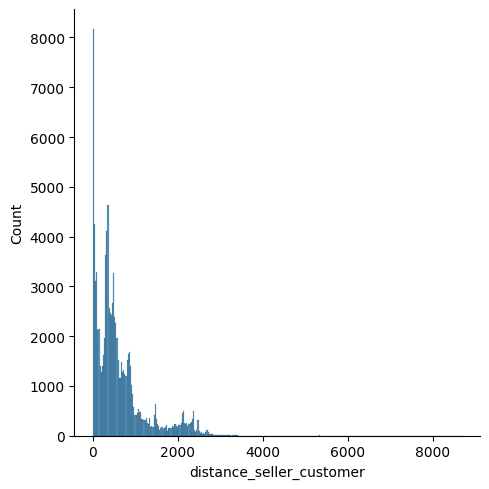

In [31]:
sns.displot(data = matching_geo, x ='distance_seller_customer')

👉 Satıcı-müşteri mesafesinin medyanı ve ortalaması nedir?

In [32]:
matching_geo['distance_seller_customer'].describe()

count    98175.000000
mean       601.693923
std        594.948984
min          0.000000
25%        187.211886
50%        433.808797
75%        798.427869
max       8677.911622
Name: distance_seller_customer, dtype: float64

👀 Yeni DataFrame'inizi kontrol edin ve kod çalıştığında `olist/order.py` içine taşıyın.

In [33]:
Order().get_distance_seller_customer()['distance_seller_customer']

0         301.504681
1         585.563937
2         312.343511
3         293.168420
4         646.163463
            ...     
98170    2754.537709
98171     351.729420
98172     339.056961
98173      72.335998
98174     134.980397
Name: distance_seller_customer, Length: 98175, dtype: float64

🧪 Kodunuzu test edin

In [34]:
from nbresult import ChallengeResult

result = ChallengeResult('distance',
    mean = Order().get_distance_seller_customer()['distance_seller_customer'].mean())
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-9.0.3, pluggy-1.6.0 -- /home/doruk/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/doruk/data-orders
configfile: pytest.ini
plugins: anyio-4.13.0
collecting ... collected 1 item

test_distance.py::TestDistance::test_distance PASSED                     [100%]

============================== 1 passed in 0.09s ===============================


💯 You can commit your code:

git add tests/distance.pickle

git commit -m 'Completed distance step'

git push origin master



Ayrıca `with_distance_seller_customer` `True` olarak ayarlandığında `get_training_data`'yı `get_distance_seller_customer` ile birleştirecek şekilde güncelleyin.

⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!